计算分数 (仅加载权重推理, 不重训)            checkpoint=.ep05 end='2024-12-31 23:59:59' start='2024-01-01 00:00:00'
已加载模型                          checkpoint=.ep05 device=cuda freq_names=['5m', '30m'] mode=online model_class=StockTransformerV3 path=/home/aiuser/work/bigalpha_best/transformer_model.json.ep05
构建测试集并预测                       end='2024-12-31 23:59:59' freqs=['5m', '30m'] mode=online start='2024-01-01 00:00:00'
[2026-07-15 14:07:17] [info     ] infer 集 5m 构建完成                samples=290706
[2026-07-15 14:07:30] [info     ] infer 集 30m 构建完成               samples=290634
[2026-07-15 14:07:52] [info     ] infer 集构建完成 (多频率)              elapsed=85.37 n_freqs=2 samples=290634
分数构建完成                         days=242 instruments=1206 mode=online rows=241770
        date instrument     score
0 2024-01-02  000006.SZ -0.019554
1 2024-01-02  000012.SZ  0.018622
2 2024-01-02  000016.SZ -0.157605
3 2024-01-02  000019.SZ  0.013721
4 2024-01-02  000025.SZ -0.035791
5 2024-01-02  000028.SZ -0.033168
6 202

时段,IC
2024-01-15~2024-02-08,-0.0053
2024-09-24~2024-10-08,0.0583

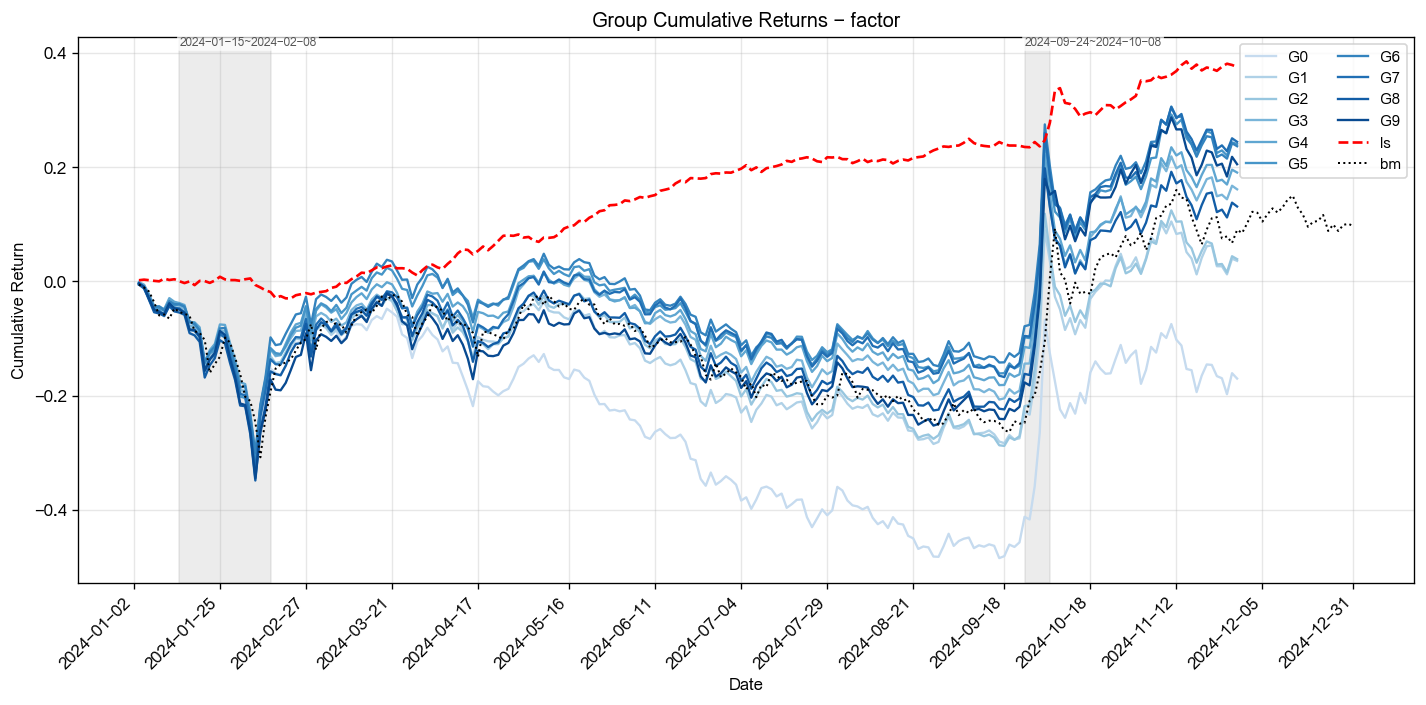
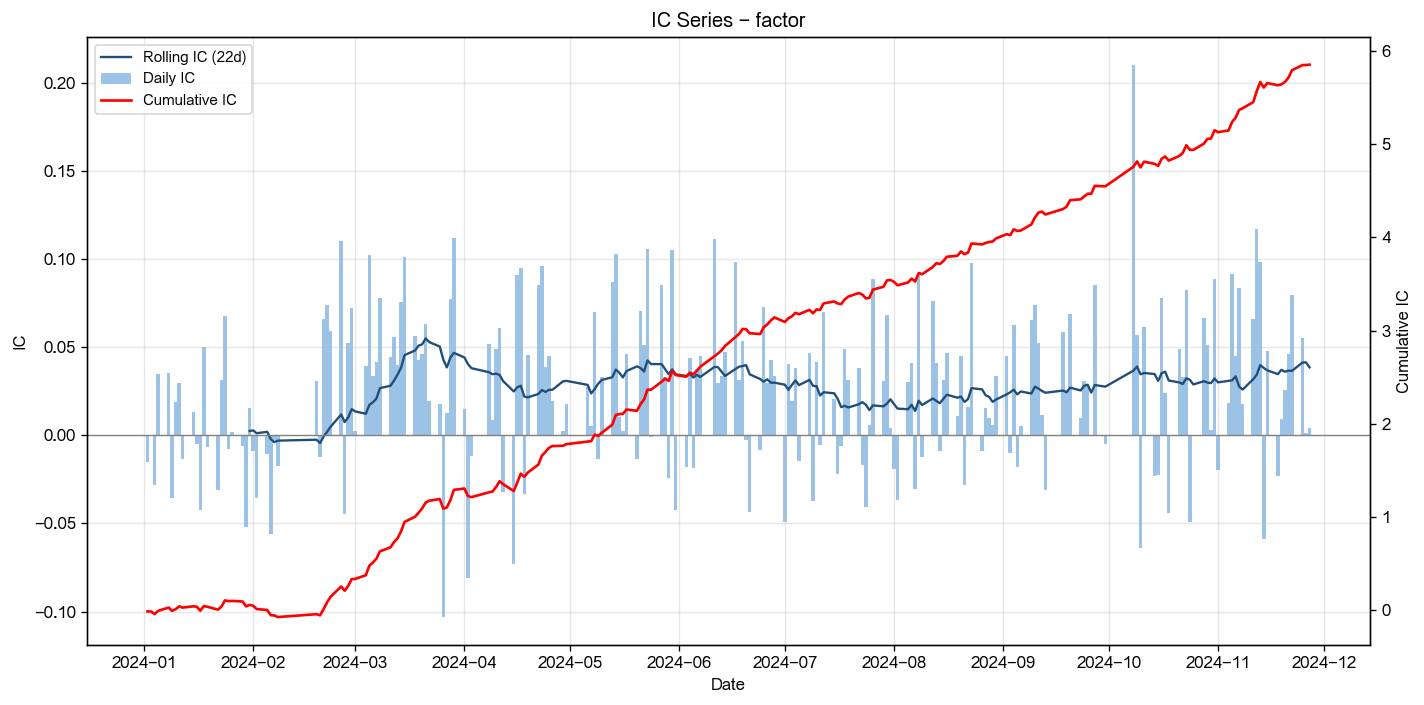
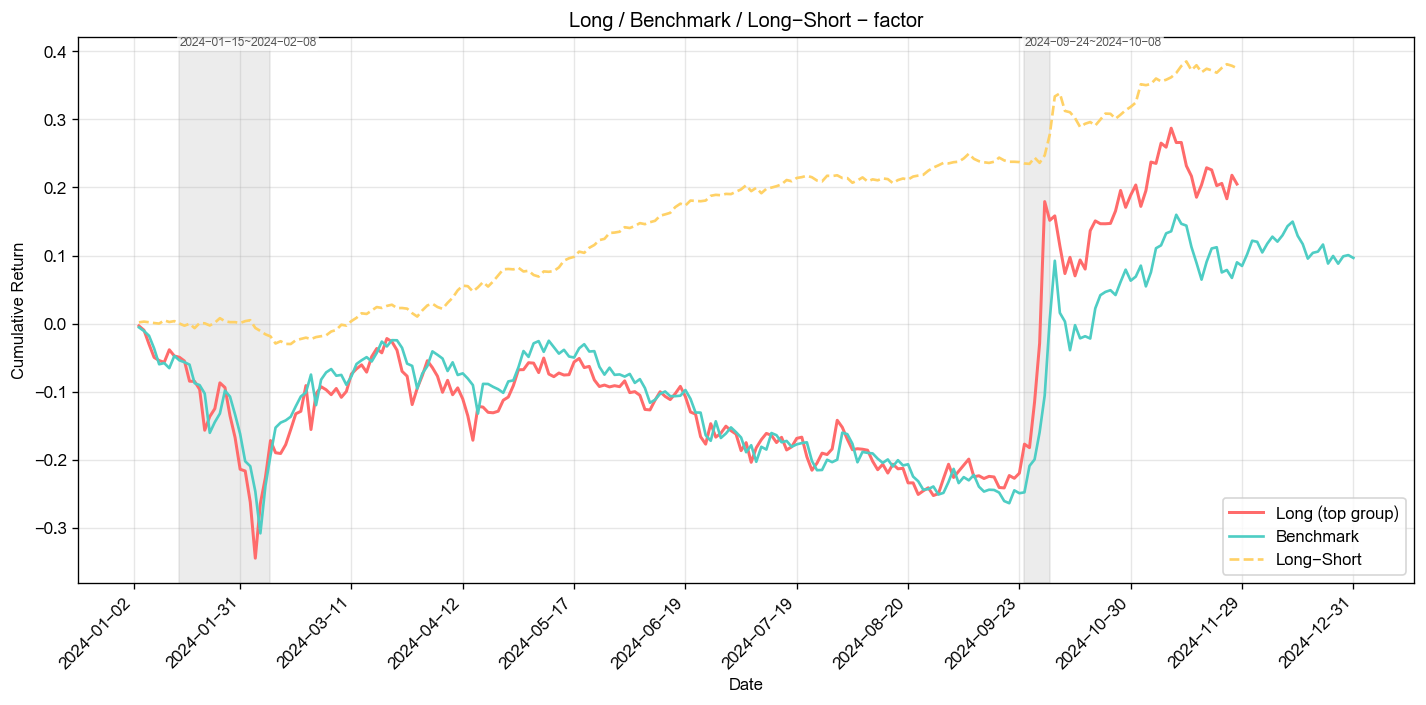
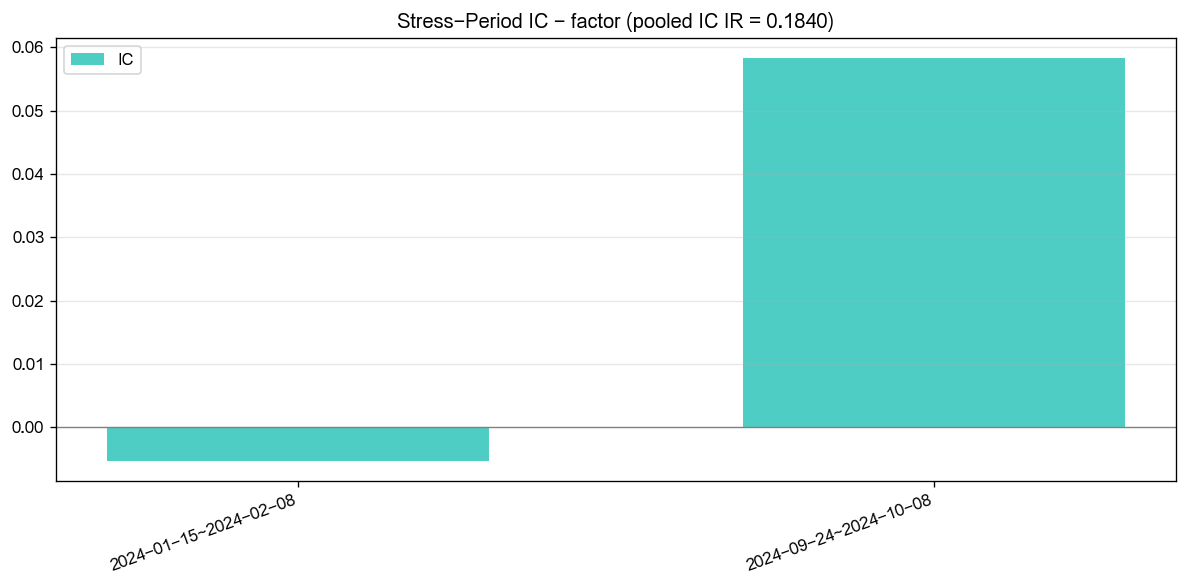
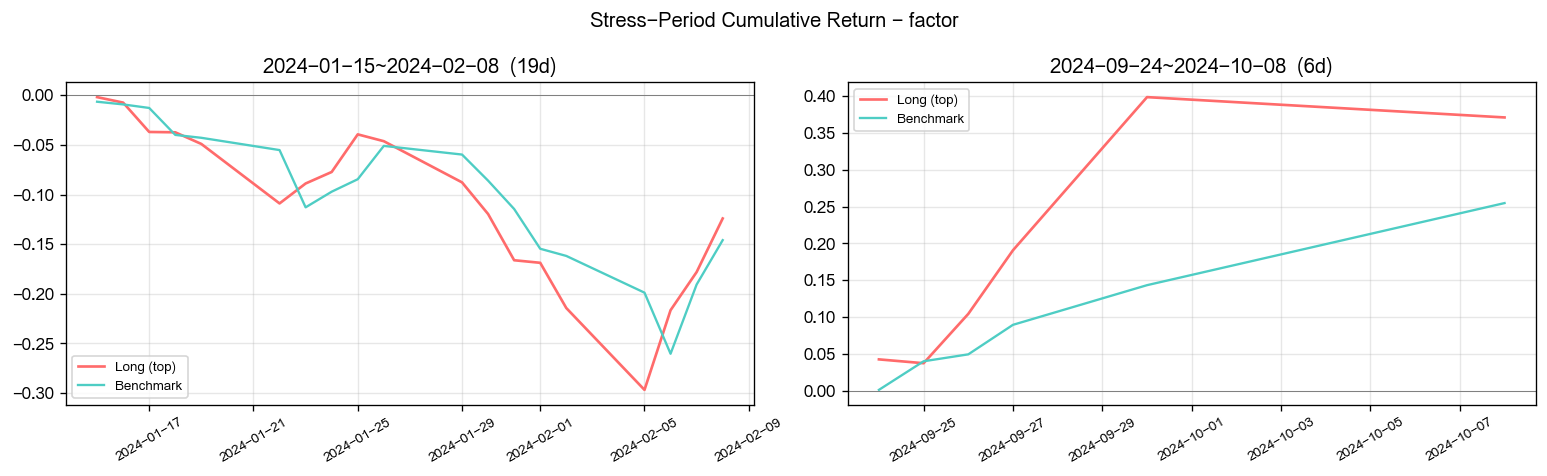

[2026-07-15 14:08:26] [warning  ] 未传入因子池，跳过因子池回归检验
[2026-07-15 14:08:26] [warning  ] 返回的Outputs实例(size=35298838) 大于 64K, 将不会被缓存
[2026-07-15 14:08:26] [info     ] bigalpha_eval.v4 运行完成 [12.956s].


In [1]:
# ==== 导入共享定义 (配置 / 模型 / 数据构建 / 训练) ====
# config.MODE 决定本地/在线行为, 模型与流程保持一致
import os
import sys
import numpy as np
import pandas as pd
import torch
import structlog

# 确保当前目录在 path 中
_HERE = os.path.dirname(os.path.abspath(__file__)) if "__file__" in dir() else os.getcwd()
if _HERE not in sys.path:
    sys.path.insert(0, _HERE)

import config
from train import (
    StockTransformer, StockTransformerV2, StockTransformerV3, build_dataset,
    load_model, save_model, load_stats,
)

logger = structlog.get_logger()


# ═══════════════════════════════════════════════════════════════════════════
# main — 平台推理入口 (签名与在线版一致)
# ═══════════════════════════════════════════════════════════════════════════
def main(datasources, start_date, end_date):
    """加载已训练模型, 在测试区间上推理打分。

    本函数**不训练**: 权重来自随 notebook 上传的 MODEL_PATH 文件。
    通过 config.MODEL_CHECKPOINT 选择加载哪个检查点 (如 ".best", ".ep05")。

    自动根据 checkpoint 中的 model_class 字段选择 StockTransformer (V1)、
    StockTransformerV2 (V2) 或 StockTransformerV3 (V3) 模型类, 兼容新旧架构。
    """
    # 仅选取 config.FREQ_TABLES 中启用的频率, 避免与模型训练时的频率数不匹配
    tables = {k.replace("bar", ""): v for k, v in datasources.items()
              if k.startswith("bar") and k.replace("bar", "") in config.FREQ_TABLES}
    if not tables:
        raise ValueError("datasources 中未找到 bar 频率表 (如 bar1m/bar5m/...)")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model_path = config.MODEL_PATH + config.MODEL_CHECKPOINT

    if not os.path.exists(model_path):
        avail = []
        for suffix in ["", ".best"] + [f".ep{e:02d}" for e in range(1, 31)]:
            p = config.MODEL_PATH + suffix
            if os.path.exists(p):
                avail.append(suffix if suffix else "(默认)")
        hint = f"\n可用检查点: {', '.join(avail)}" if avail else ""
        raise FileNotFoundError(
            f"未找到模型文件 {model_path}; 请先运行 train.py 训练并保存{hint}")

    ckpt = load_model(model_path, map_location=device)
    config.check_model_data_compat(ckpt["model_cfg"], tables)

    stats = (np.asarray(ckpt["mean"], np.float32), np.asarray(ckpt["std"], np.float32))

    # 根据 model_class 选择对应的模型架构 (兼容 V1 / V2 / V3)
    model_cls_name = ckpt.get("model_class", "StockTransformer")
    if model_cls_name == "StockTransformerV3":
        model = StockTransformerV3(**ckpt["model_cfg"]).to(device)
    elif model_cls_name == "StockTransformerV2":
        model = StockTransformerV2(**ckpt["model_cfg"]).to(device)
    else:
        model = StockTransformer(**ckpt["model_cfg"]).to(device)
    model.load_state_dict(ckpt["state_dict"])
    model.eval()

    ckpt_tag = config.MODEL_CHECKPOINT or "(默认)"
    logger.info("已加载模型", path=model_path, checkpoint=ckpt_tag,
                model_class=model_cls_name,
                device=str(device), mode=config.MODE,
                freq_names=ckpt.get("freq_names", []))

    instruments = config.pool(start_date, end_date)
    if config.MODE == "local":
        instruments = instruments[:config.MAX_TRAIN_INSTRUMENTS]

    logger.info("构建测试集并预测", start=start_date, end=end_date,
                freqs=list(tables.keys()), mode=config.MODE)
    Xte, _, idx_df, _ = build_dataset(tables, start_date, end_date, "infer",
                                       instruments, stats)

    preds = []
    Xte_t = torch.from_numpy(Xte)
    with torch.no_grad():
        for i in range(0, len(idx_df), config.BATCH):
            xb = Xte_t[i:i + config.BATCH].to(device)
            preds.append(model(xb).cpu().numpy())
    idx_df["score"] = np.concatenate(preds).astype(np.float64)

    if config.MODE == "local":
        idx_df["instrument"] = idx_df["instrument_id"].apply(config.resolve_instrument)

    if config.MODE == "online":
        import dai
        stk = dai.query("SELECT date, instrument FROM bigalpha_2026_instruments",
                        filters={"date": [start_date, end_date]}).df()
        result = (pd.merge(idx_df, stk, on=["date", "instrument"], how="inner")
                    .replace([np.inf, -np.inf], np.nan).dropna(subset=["score"])
                    .drop_duplicates(["date", "instrument"])[["date", "instrument", "score"]]
                    .reset_index(drop=True))
    else:
        result = (idx_df
                    .replace([np.inf, -np.inf], np.nan).dropna(subset=["score"])
                    .drop_duplicates(["date", "instrument"])[["date", "instrument", "score"]]
                    .reset_index(drop=True))

    logger.info("分数构建完成", rows=len(result), days=result["date"].nunique(),
                instruments=result["instrument"].nunique(), mode=config.MODE)
    return result


# ═══════════════════════════════════════════════════════════════════════════
# 本地测试入口 (在线平台不会执行此段)
# ═══════════════════════════════════════════════════════════════════════════
if __name__ == "__main__":
    datasources = {f"bar{k}": v for k, v in config.FREQ_TABLES.items()}

    if config.MODE == "local":
        start_date = config.VAL_START
        end_date = config.VAL_END
    else:
        start_date, end_date = "2024-01-01 00:00:00", "2024-12-31 23:59:59"

    ckpt_tag = config.MODEL_CHECKPOINT or "(默认)"
    logger.info("计算分数 (仅加载权重推理, 不重训)",
                checkpoint=ckpt_tag, start=start_date, end=end_date)
    score_data = main(datasources, start_date, end_date)
    print(score_data.head(10))
    print(f"\n总行数: {len(score_data)}, 交易日数: {score_data['date'].nunique()}, "
          f"股票数: {score_data['instrument'].nunique()}")

    # score_data.to_csv(os.path.join(_HERE, "scores.csv"), index=False)
    # logger.info("分数已保存", path=os.path.join(_HERE, "scores.csv"))

    if config.MODE == "online":
        from bigmodule import M
        logger.info("开始评估分数")
        result = M.bigalpha_eval._latest(factor_data=score_data, show=True)